In [1]:
# Imports
import numpy as np
import pandas as pd
from scipy.linalg import lstsq
from sympy import *
import matplotlib.pyplot as plt
init_printing(use_latex=true)
filename = "DataFormattedSep1TFTOnly.xlsx"

# Input real data


In [2]:
# Establish number of wells
n = pd.read_excel(filename, sheet_name='n').iloc[0,0]
n

6

In [3]:
# Establish number of timepoints
T = pd.read_excel(filename, sheet_name='T').iloc[0,0]
T

4092

In [4]:
zReal = pd.read_excel(filename, sheet_name="OnOff").to_numpy().T   # Only binary at this point
zReal[pd.isna(zReal)] = 0
zReal

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 1., 1.],
       [0., 0., 0., ..., 1., 1., 0.]])

In [5]:
tftReal = pd.read_excel(filename, sheet_name="TFTs").to_numpy().T   # Non-binary, contains TFT measurement.
tftReal[pd.isna(tftReal)] = 0
numTfts = np.count_nonzero(tftReal)
tftReal

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [6]:
dReal = np.zeros(tftReal.shape)
for r in range(len(dReal)):
    for c in range(len(dReal[0])):
        if tftReal[r,c] != 0:
            dReal[r,c] = 1
dReal

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [7]:
# Establish vector of expert-estimated mass flows
mEstimates = pd.read_excel(filename, sheet_name="MassFlowEstimates").to_numpy().T
mEstimates[pd.isna(mEstimates)] = 0
mEstimates

array([[37.850415  , 37.84663588, 37.86923759, ..., 21.25723254,
        21.58338482, 21.43937503],
       [19.82577246, 19.79792847, 19.96729681, ..., 18.71403498,
        18.171498  , 16.85674925],
       [45.32463838, 45.24350869, 45.3978868 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ..., 38.30744017,
        38.30412326, 38.3096444 ],
       [ 0.        ,  0.        ,  0.        , ..., 10.04570769,
         9.98935546,  0.        ]])

In [8]:
# Establish vector of total mass flow at the separator over time
MReal = pd.read_excel(filename, sheet_name="TotalMassFlow").to_numpy().T
MReal[pd.isna(MReal)] = 0
MReal

array([[103.00082583, 102.88807305, 103.23442119, ...,  88.32441538,
         88.04836154,  76.60576868]])

In [14]:
# Check shapes of matrices
MReal.shape, mEstimates.shape, zReal.shape, tftReal.shape, dReal.shape

In [10]:
# Check for any NA values
sum(sum(pd.isna(MReal))), sum(sum(pd.isna(mEstimates))), sum(sum(pd.isna(zReal))), sum(sum(pd.isna(tftReal))), sum(sum(pd.isna(dReal)))

(0, 0, 0, 0, 0)

In [21]:
MReal = MReal[:,:1000]
mEstimates = mEstimates[:,:1000]
zReal = zReal[:,:1000]
tftReal = tftReal[:,:1000]
dReal = dReal[:,:1000]
T=1000

## Choose parameter values and solve model

In [22]:
# Choose value of k
k = 3

In [23]:
# Define lambda values
Lambda1 = T*n**2/numTfts
Lambda2 = 8
Lambda3 = 2
Lambda1, Lambda2, Lambda3

In [24]:
# Compile the y vector (col. vec.)
y = np.zeros([T*(n+1)+n*(T-1)+n*(T-2), 1])
for j in range(T):
    # fill in m values
    for i in range(n):
        y[T*i+j, 0] = np.sqrt(Lambda1) * tftReal[i,j] 
    # fill in M values
    y[T*n+j, 0] = MReal[0,j]
y.shape

In [25]:
# Compile the A1 matrix
A1 = np.zeros([T*(n+1)+n*(T-1)+n*(T-2), n*T])
for i in range(n):
    for j in range(T):
        # fill in d values
        A1[T*i+j, T*i+j] = np.sqrt(Lambda1) * dReal[i,j]
        # fill in z values
        A1[T*n+j, T*i+j] = zReal[i,j]
        # fill in forward difference formula to approximate the first order derivative
        if j > 0: # Ignore first row to not add a BC
            A1[T*(n+1)+i*(T-1)+j-1, i*(T)+j-1] = -1 * np.sqrt(Lambda2)
            A1[T*(n+1)+i*(T-1)+j-1, i*(T)+j] = 1 * np.sqrt(Lambda2)
        # fill in second order central difference formula to approximate the second order derivative
        if j > 1: # Ignore first two rows to not add BCs
            A1[T*(n+1)+n*(T-1)+i*(T-2)+j-2, i*(T)+j-2] = 1 * np.sqrt(Lambda3)
            A1[T*(n+1)+n*(T-1)+i*(T-2)+j-2, i*(T)+j-1] = -2 * np.sqrt(Lambda3)
            A1[T*(n+1)+n*(T-1)+i*(T-2)+j-2, i*(T)+j] = 1 * np.sqrt(Lambda3)
            
        
    
A1.shape
#A1[638:,201:]

In [26]:
# Compile the A2 matrix
# Use t's uniformly spaced 1 apart
ts = np.array(list(range(T)))+1
A2 = np.zeros([n*T, n*(k+1)])
for block in range(n):
    for r in range(T):
        for c in range(k+1):
            A2[block*T + r, block*(k+1) + c] = ts[r]**c

A2.shape

In [27]:
# Calculate final A matrix
A = np.matmul(A1,A2)
A.shape

In [28]:
# SOLVE

res, _, _, _ = lstsq(A, y)
res = res.reshape(n, k+1)
res

array([[-1.28209416e+02,  7.59769792e-01, -1.13498026e-03,
         5.50009671e-07],
       [ 2.18374825e+01,  4.91378768e-02, -1.74233041e-04,
         1.42377598e-07],
       [ 2.19760600e+02, -1.01949749e+00,  1.69288267e-03,
        -8.65059710e-07],
       [-4.83455960e+01, -1.36261253e-01,  3.83668955e-04,
        -1.71582715e-07],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00]])

## Plot Results

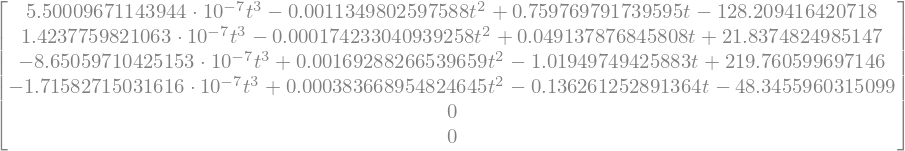

In [29]:
# Coerce results into desired format for printing
t = symbols('t')
wExpr = Matrix(np.zeros(n))
for i in range(n):
    for deg in range(k+1):
        #print(res[i,deg]*t**deg)
        wExpr[i] = wExpr[i] + res[i,deg]*t**deg

wExpr

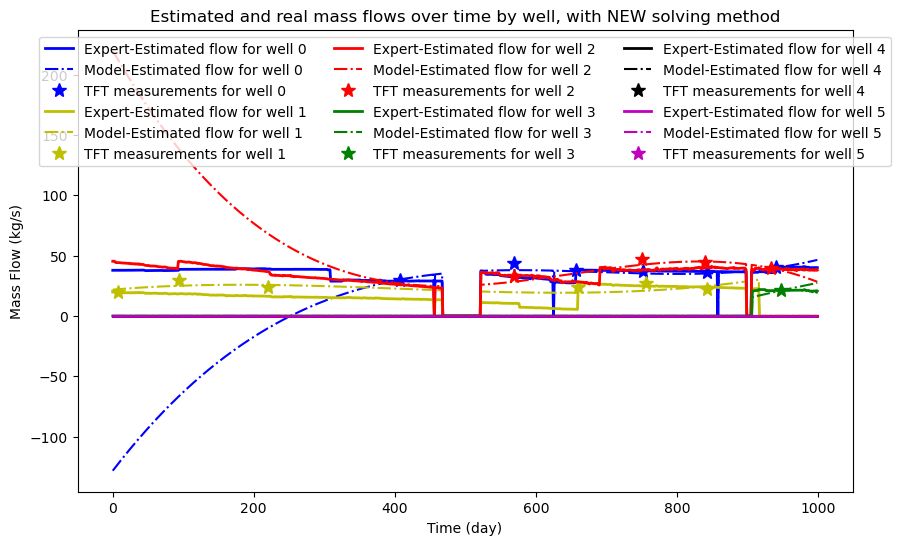

In [30]:
# Plot results from all wells
plt.figure(figsize=(10,6))
colours=['b', 'y', 'r', 'g', 'k', 'm']
for i in range(n):
    plt.plot(range(T),mEstimates[i,:][:], colours[i]+'-', lw=2, label="Expert-Estimated flow for well "+str(i))
    # Plot Time-Dependently
    toplot = []
    for time in range(T):
        resplot = wExpr[i].subs(t, time)
        toplot.append(resplot*zReal[i,time])
        #print(time, toplot)
    plt.plot(range(T),toplot, colours[i]+'-.', lw=1.5, label="Model-Estimated flow for well "+str(i))
    # Plot TFT points
    monthplot = []
    tftplot = []
    for month,element in enumerate(tftReal[i,:]):
        if element != 0:
            monthplot.append(month)
            tftplot.append(tftReal[i,month])
    plt.plot(monthplot, tftplot, colours[i]+'*', markersize=10, label="TFT measurements for well "+str(i))
            
plt.title("Estimated and real mass flows over time by well, with NEW solving method")
plt.xlabel("Time (day)")
plt.ylabel("Mass Flow (kg/s)")
#plt.legend(bbox_to_anchor=(0.9, 1.05))
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1), ncol=3, fancybox=True)

#plt.savefig("Figs/TFTOnlyA.svg")


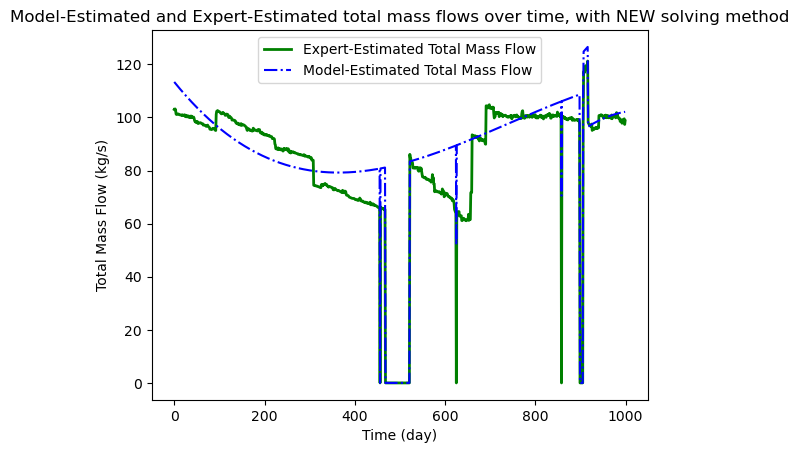

In [31]:
# Plot total flow vs found total flow
totalFlowFound = np.zeros((T,1))
times = range(T)
for time in range(T):
    tff = [wExpr[i].subs(t, time)*zReal[i,time] for i in range(n)]
    #print(t, tff)
    totalFlowFound[time] = sum(tff)

plt.plot(list(Matrix(times).T), list(MReal[0]), 'g-', lw=2, label="Expert-Estimated Total Mass Flow")
plt.plot(times,totalFlowFound, 'b-.', lw=1.5, label="Model-Estimated Total Mass Flow")

plt.title("Model-Estimated and Expert-Estimated total mass flows over time, with NEW solving method")
plt.xlabel("Time (day)")
plt.ylabel("Total Mass Flow (kg/s)")
plt.legend()

#plt.savefig("Figs/TFTOnlyB.svg")